# Classification of Titanic passengers

- Let's load the dataset

In [14]:
import pandas as pd
pd.set_option("display.max_columns", None)

titanic_df = pd.read_csv('titanic.csv', index_col='PassengerId')
titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



## Data preparation

#### Train/Test Split & Cross-Validation

We split the data into 80% training and 20% test sets, then use 5-fold stratified cross-validation on the training set for model validation. Every model gets the same folds to ensure fairness.

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from data_processing import TitanicFeatureBuilder

X_train, X_test, y_train, y_test = train_test_split(
    titanic_df.drop(columns="Survived"), titanic_df["Survived"],
    test_size=0.2, stratify=titanic_df["Survived"], random_state=42
)

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

folds = list(skf.split(X_train, y_train))

#### Data processing

Let's process the data according to the EDA from the 1st exercise and PR review.

In [16]:
numeric_features = ["Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize"]
categorical_features = ["Sex", "Embarked", "Title", "Deck"]
preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_features),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

def make_pipeline(model):
    return Pipeline([("features", TitanicFeatureBuilder()), ("preprocessor", preprocessor), ("model", model)])


## Model Training & Evaluation
### Baseline
We will take DummyClassifier and test how it manages.

Dummy Classifier Evaluation Results:


b:\Dependencies\python_3_13\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
b:\Dependencies\python_3_13\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
b:\Dependencies\python_3_13\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
b:\Dependencies\python_3_13\Lib\site-packages\sklearn\m

,CV mean,CV std
accuracy,0.617,0.003
precision,0.000,0.000
recall,0.000,0.000
f1,0.000,0.000


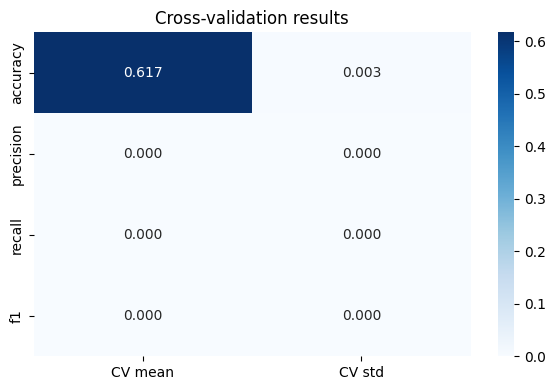

In [17]:
from model_training.common import evaluate_model, print_evaluation_results
from sklearn.dummy import DummyClassifier
import numpy as np

dummy = DummyClassifier(strategy="most_frequent")

dummy_scores = evaluate_model(dummy, X_train, y_train, folds)

print("Dummy Classifier Evaluation Results:")
print_evaluation_results(dummy_scores)


Overall dummy achieves 61% accuracy using the most_frequent strategy, not having identified correctly any survivors (f1 = 0). <br>
The uniform strategy performed much worse, so I didn't include it here.

### KNN

Now we will take KNN to see how it performs.

K-Nearest Neighbors Evaluation Results:


,CV mean,CV std
accuracy,0.808,0.014
precision,0.783,0.047
recall,0.696,0.056
f1,0.735,0.021


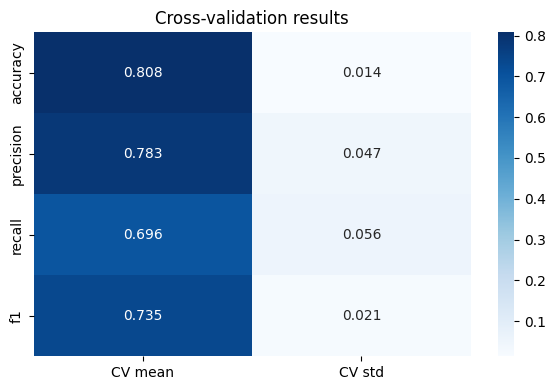

In [18]:
from sklearn.neighbors import KNeighborsClassifier

knn = make_pipeline(KNeighborsClassifier(n_neighbors=5))

knn_scores = evaluate_model(knn, X_train, y_train, folds)
print("K-Nearest Neighbors Evaluation Results:")
print_evaluation_results(knn_scores)

KNN achieves 80% accuracy so outperforming dummy by 19%, with relatively low spread too. 
Precision was a little bit higher than recall - it recognizes survivals quite well but doesn't recognise all the cases. Nevertheless it's not bad.

#### Hyperpamaters

Let's find the best-performing hyperparameter combination:

In [19]:
from model_training.common import run_hyperparameter_tuning
from sklearn.neighbors import KNeighborsClassifier

param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "cosine", "manhattan"]
}

[best_model, best_params, best_score, cv_results] = run_hyperparameter_tuning(
    make_pipeline(KNeighborsClassifier()),
    param_grid,
    X_train,
    y_train,
    folds
)

print("K-Nearest Neighbors Hyperparameter Tuning Results:")
print(f"Best parameters: {best_params}")
print(f"Best cross-validation score: {best_score:.4f}")

from sklearn.metrics import classification_report
print("Final test-set metrics (test set was not used during tuning):")
print(classification_report(y_test, best_model.predict(X_test)))

K-Nearest Neighbors Hyperparameter Tuning Results:
Best parameters: {'model__metric': 'manhattan', 'model__n_neighbors': 15, 'model__weights': 'uniform'}
Best cross-validation score: 0.8231
Final test-set metrics (test set was not used during tuning):
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       110
           1       0.82      0.68      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.82       179



So actually, the model improved to 82% same as in the test set. It got a little bit less pessimistic as the model above, but the precision is much better. 
Let's plot the hyperparameters:

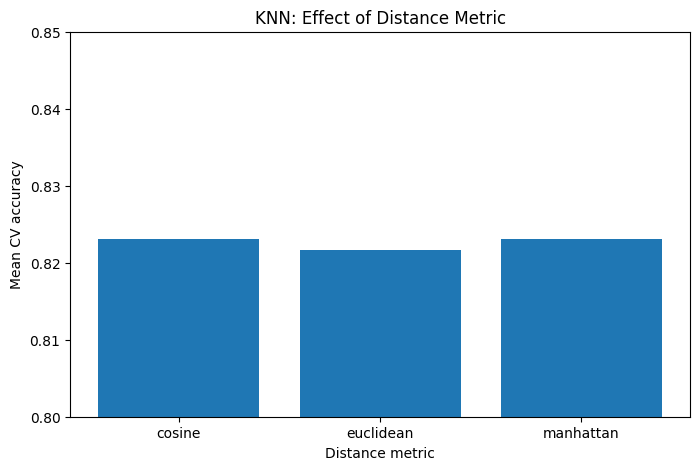

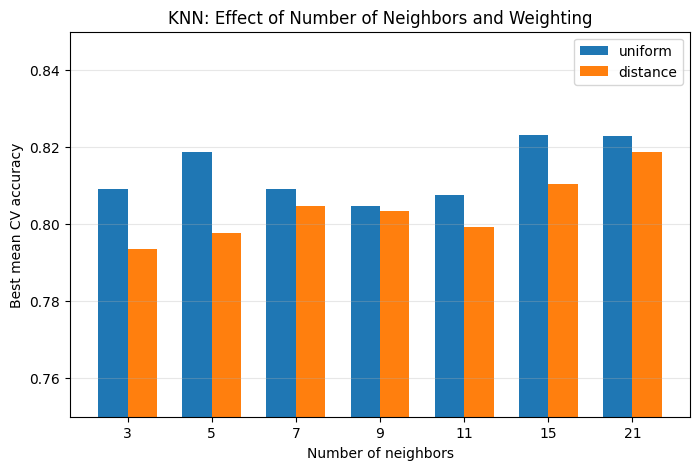

In [20]:
import matplotlib.pyplot as plt
import pandas as pd

results = pd.DataFrame(cv_results)

metric_results = (
    results
    .groupby("param_model__metric")["mean_test_score"]
    .max()
)

plt.figure(figsize=(8, 5))
plt.bar(
    metric_results.index,
    metric_results.values
)
plt.xlabel("Distance metric")
plt.ylabel("Mean CV accuracy")
plt.title("KNN: Effect of Distance Metric")
plt.ylim(0.8, 0.85)
plt.show()

neighbor_results = (
    results
    .groupby(["param_model__n_neighbors", "param_model__weights"])["mean_test_score"]
    .max()
    .reset_index()
)

plt.figure(figsize=(8, 5))

neighbors = sorted(neighbor_results["param_model__n_neighbors"].unique())
x = np.arange(len(neighbors))
width = 0.35

for i, weights in enumerate(["uniform", "distance"]):
    data = (
        neighbor_results[
            neighbor_results["param_model__weights"] == weights
        ]
        .set_index("param_model__n_neighbors")
    )

    plt.bar(
        x + (i - 0.5) * width,
        [data.loc[n, "mean_test_score"] for n in neighbors],
        width=width,
        label=weights
    )

plt.xticks(x, neighbors)
plt.xlabel("Number of neighbors")
plt.ylabel("Best mean CV accuracy")
plt.title("KNN: Effect of Number of Neighbors and Weighting")
plt.legend()
plt.ylim(0.75, 0.85)
plt.grid(axis="y", alpha=0.3)

plt.show()

So as we can see, there are some key observations:
1) So cosine performed best, suggesting that overall similarity between passenger profiles (linked featues) is more useful than absolute distance between feature differences.
2) 15 neighbors performed the best for uniform, 21 was best for distance. 

### XGBoost

Let's see how the boosted trees will do:

XGBoost Evaluation Results:


,CV mean,CV std
accuracy,0.812,0.027
precision,0.766,0.052
recall,0.736,0.029
f1,0.750,0.032


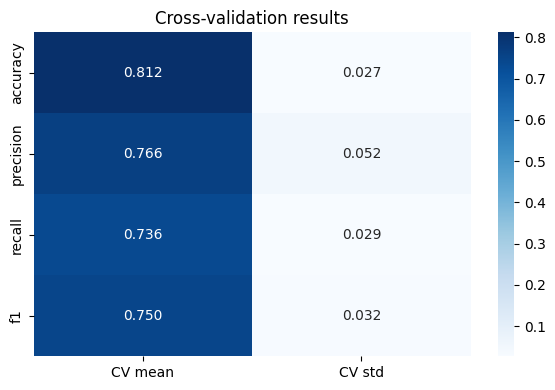

In [8]:
from xgboost import XGBClassifier

xgb = make_pipeline(XGBClassifier(
    random_state=67,
    eval_metric="logloss"
))

xgb_scores = evaluate_model(xgb, X_train, y_train, folds)

print("XGBoost Evaluation Results:")
print_evaluation_results(xgb_scores)

XGBoost achieves 81.2% accuracy with a relatively low spread, already performing close to the fine-tuned KNN. This suggests that boosted trees may be a better fit for this dataset than KNN, but we will verify this after hyperparameter tuning.

#### Hyperpamaters

Let's find the best-performing hyperparameter combination:

In [12]:
from xgboost import XGBClassifier
from model_training.common import run_hyperparameter_tuning
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


param_grid = {
    "model__n_estimators": [50, 100, 200, 300],
    "model__learning_rate": [0.005, 0.01, 0.03, 0.1, 0.2, 0.3],
    "model__max_depth": [3, 4, 5],
    "model__min_child_weight": [0, 1, 3, 5]
}


best_model, best_params, best_score, cv_results = run_hyperparameter_tuning(
    make_pipeline(XGBClassifier(
        random_state=67,
        objective="binary:logistic",
        tree_method="hist",
        eval_metric="logloss",
        n_jobs=1
    )),
    param_grid,
    X_train,
    y_train,
    folds
)


print("XGBoost Hyperparameter Tuning Results:")
print(f"Best parameters: {best_params}")
print(f"Best cross-validation score: {best_score:.4f}")

XGBoost Hyperparameter Tuning Results:
Best parameters: {'model__learning_rate': 0.005, 'model__max_depth': 4, 'model__min_child_weight': 0, 'model__n_estimators': 200}
Best cross-validation score: 0.8455


The model achieved 84.4% cross-validation accuracy, so better than KNN and dummy.
Let's see the hyperparameters on a chart:

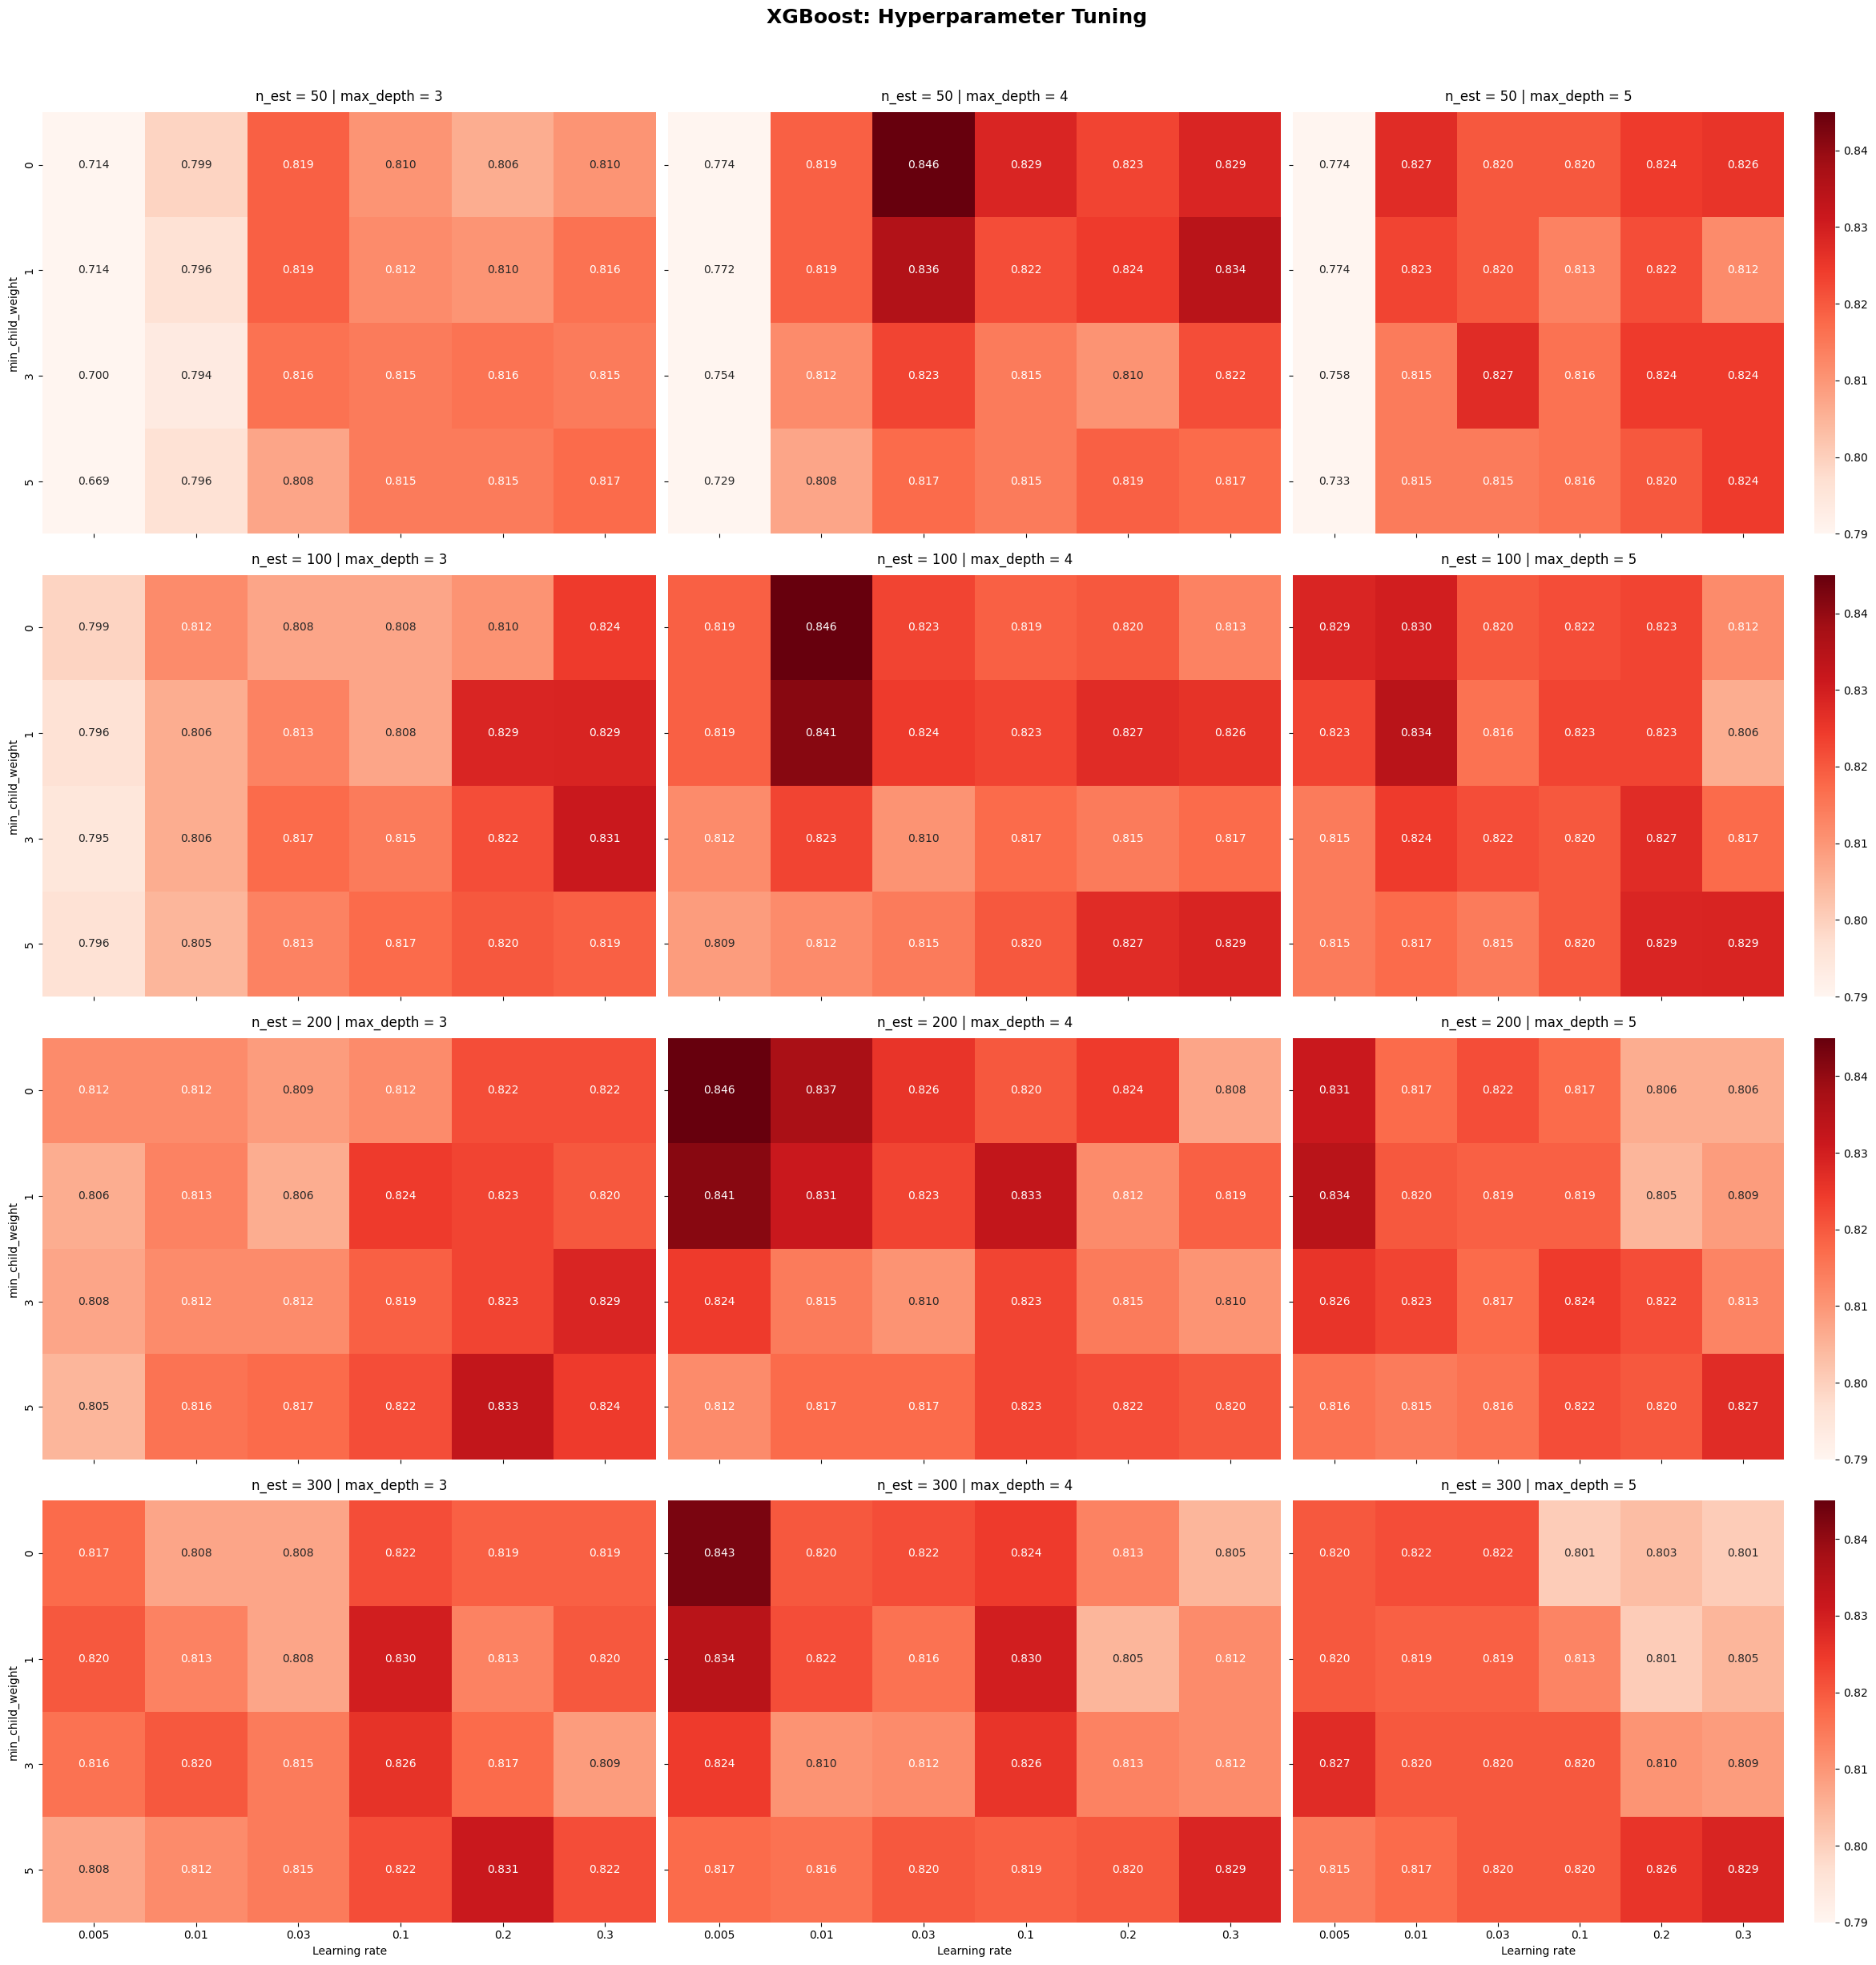

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from model_training.plots import plot_hyperparameter_tuning_results

plot_hyperparameter_tuning_results(cv_results)

Okay, that's a lot but generally the best score are in the column with max_depth of 4 with quite a small learning rate. In fact we can see a pattern when we multiply n_est * learning rate and somewhere equal to one we will have the highest scores.

- With max-depth = 3 we can see that the model performs better when it learns more, but actually this is a sign of overfitting, which is also shown below.
- Models with max-depth of 5 are too general and appear to be relativly worse. There is also some noise and there is no outstanding pattern. 
- Low learning rate prevented from overfitting.

Let's take the best model and see how it managed:

In [11]:
from sklearn.metrics import classification_report
print("Final test-set metrics (test set was not used during tuning):")
print(classification_report(y_test, best_model.predict(X_test)))

Final test-set metrics (test set was not used during tuning):
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.79      0.72      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



So 82%, quite good, at least as good as KNN, maybe it was a little bit overfitted, from precision/recall we can see that it generally wasn't optimistic and was more prefering to choose that the person didn't survive. It had for sure a little bi better precision when it comes to not-survived people, than survived. It's not as even as in KNN.